# Static stability of a prescribed 3D eddy
Prescribe an axisymmetric eddy from its vorticity, get the density anomaly needed for
gradient-wind + hydrostatic balance, add it to a background profile, check if $N^2<0$.

$$\omega(r)=s\,\omega_0 e^{-(r/R)^n},\quad
v_\theta=\frac{1}{r}\!\int_0^r\! r'\omega\,dr',\quad
\nabla_h^2P'=\rho_s\big[f\zeta+2(u_xv_y-v_xu_y)\big],\quad
\rho'=-\frac{1}{g}\frac{\partial P'}{\partial z},\quad
N^2=-\frac{g}{\rho_0}\frac{\partial(\rho_s+\rho')}{\partial z}$$

**Usage:** run all cells. Edit only cell 2 (background) and cell 3 (eddy parameters).
Requires `numpy`, `scipy`, `matplotlib`. Convention: `z` is negative downward, surface first.
`polarity = +1` is cyclonic (in both hemispheres).

In [15]:
import numpy as np, matplotlib.pyplot as plt
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import splu
g = 9.81

## 1. Background profile — replace with your own `z`, `rho_s`, `f0`, `Rd`

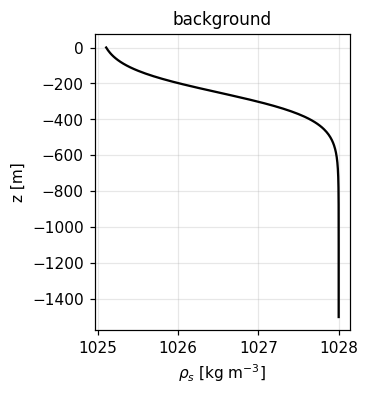

In [21]:
# analytical example: mixed layer above a pycnocline
z     = np.arange(0., -1501., -5.)                      # depth [m], negative down
rho_s = 1025. + 1.5*(1. - np.tanh((z + 250.)/150.))     # background density [kg/m3]
f0    = 8e-5                                            # Coriolis [1/s]
Rd    = 30.                                             # Rossby radius [km]


rho0 = rho_s.mean()
plt.figure(figsize=(3,3.5)); plt.plot(rho_s, z, 'k')
plt.xlabel(r'$\rho_s$ [kg m$^{-3}$]'); plt.ylabel('z [m]'); plt.title('background'); plt.show()

## 2. Eddy parameters

In [32]:
polarity    = +1        # +1 cyclonic, -1 anticyclonic
Ro          = 0.1       # Rossby number V0/(|f0| R)
R           = 15e3      # eddy radius [m]
H           = 50.       # vertical scale [m]
z_eddy      = -300.        # depth of the core [m] (0 = surface)
vshape      = 'gauss'     # 'exp' = surface-intensified, 'gauss' = subsurface
power_shape = 20        # vorticity edge steepness (2 = smooth, 20 = top-hat)
balance     = 'ageo'    # 'ageo' = gradient-wind, 'geo' = geostrophic
L, n        = 60e3, 100 # domain size [m] and number of grid cells

## 3. Build the eddy

In [33]:
def build_eddy(z, rho_s, f0, polarity, Ro, R, H, z_eddy,
               vshape='exp', power_shape=20, balance='ageo', L=60e3, n=100):
    """Return x, y, u, v, density anomaly and SSH of a balanced eddy."""
    V0 = Ro*abs(f0)*R
    d  = L/n
    xx, yy = np.meshgrid(np.linspace(0, L, n+1), np.linspace(0, L, n+1))
    r, th  = np.hypot(xx-L/2, yy-L/2), np.arctan2(yy-L/2, xx-L/2)

    # azimuthal velocity from the prescribed vorticity, rescaled to peak at V0
    rw = np.arange(100., 2*L, 100.)
    vw = np.cumsum(rw*np.exp(-(rw/R)**power_shape)*100.)/rw
    vt = np.interp(r, rw, V0*np.sign(f0)*polarity*vw/np.abs(vw).max(), left=0.)

    F = np.exp((z-z_eddy)/H) if vshape == 'exp' else np.exp(-(z-z_eddy)**2/(2*H**2))
    u = -vt*np.sin(th)*F[:, None, None]
    v = +vt*np.cos(th)*F[:, None, None]
    u *= V0/np.abs(u).max(); v *= V0/np.abs(v).max()

    ux, uy = np.gradient(u, axis=2)/d, np.gradient(u, axis=1)/d
    vx, vy = np.gradient(v, axis=2)/d, np.gradient(v, axis=1)/d
    rhs = rho_s[:, None, None]*(f0*(vx-uy) + (2*(ux*vy-vx*uy) if balance == 'ageo' else 0.))

    # 5-point Laplacian, P' = 0 on the boundaries
    D = diags([1., -2., 1.], [-1, 0, 1], shape=(n-1, n-1))/d**2
    lu = splu((kron(D, identity(n-1)) + kron(identity(n-1), D)).tocsc())
    P = np.zeros_like(rhs)
    for k in range(len(z)):
        P[k, 1:-1, 1:-1] = lu.solve(rhs[k, 1:-1, 1:-1].ravel()).reshape(n-1, n-1)

    rho_a = -np.gradient(P, axis=0)/np.gradient(z)[:, None, None]/g
    return xx, yy, u, v, rho_a, P[0]/(rho_s.mean()*g)


xx, yy, u, v, rho_a, ssh = build_eddy(z, rho_s, f0, polarity, Ro, R, H, z_eddy,
                                      vshape, power_shape, balance, L, n)
ic = n//2                                   # index of the eddy centre
rho_c = rho_a[:, ic, ic]                    # density anomaly at the centre
N2    = -g/rho0*np.gradient(rho_s + rho_c)/np.gradient(z)
print(f"max |rho'| = {np.abs(rho_a).max():.3f} kg/m3, SSH = {ssh[ic, ic]:+.3f} m, "
      f"min N2 = {N2[1:-1].min():.2e} s-2, unstable = {(N2[1:-1] < 0).sum() > 3}")

max |rho'| = 0.300 kg/m3, SSH = -0.000 m, min N2 = 2.36e-11 s-2, unstable = False


## 4. Structure and stability

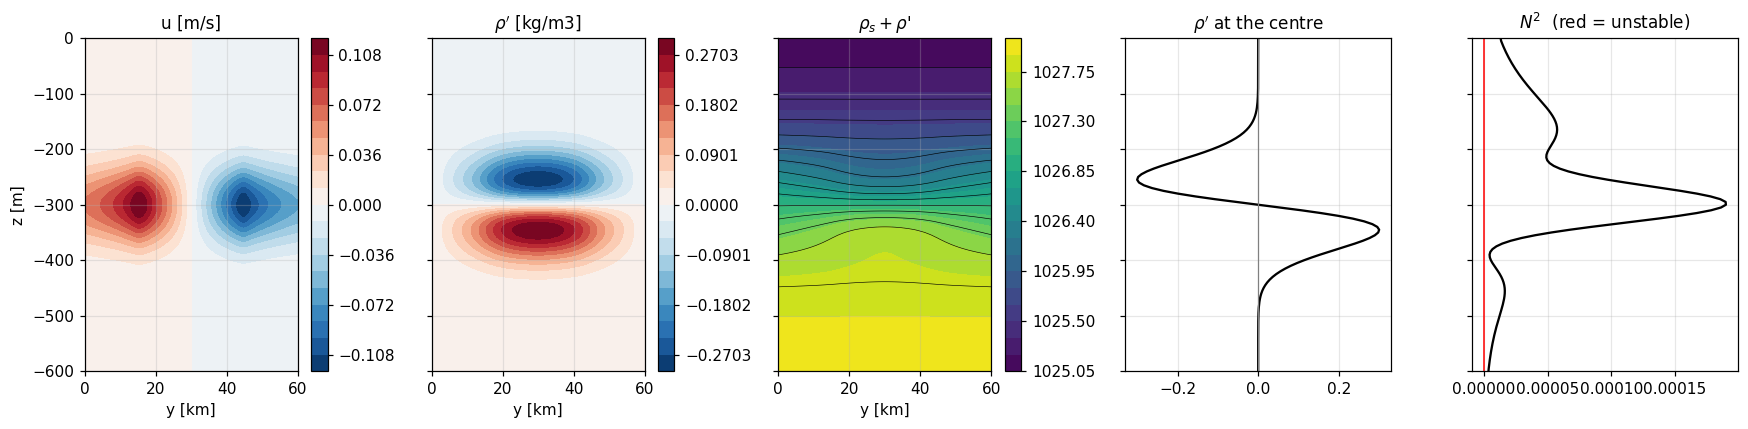

In [34]:
zmin = -600
y2d, z2d = np.tile(yy[:, ic], (len(z), 1))/1e3, np.tile(z, (n+1, 1)).T

fig, ax = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
for a, f, t, cm in [(ax[0], u[:, :, ic], 'u [m/s]', 'RdBu_r'),
                    (ax[1], rho_a[:, :, ic], r"$\rho'$ [kg/m3]", 'RdBu_r')]:
    m = np.abs(f).max()
    c = a.contourf(y2d, z2d, f, np.linspace(-m, m, 21), cmap=cm)
    fig.colorbar(c, ax=a); a.set_title(t)
c = ax[2].contourf(y2d, z2d, rho_s[:, None] + rho_a[:, :, ic], 25, cmap='viridis')
ax[2].contour(y2d, z2d, rho_s[:, None] + rho_a[:, :, ic], 15, colors='k', linewidths=.4)
fig.colorbar(c, ax=ax[2]); ax[2].set_title(r'$\rho_s+\rho$'"'")

ax[3].plot(rho_c, z, 'k'); ax[3].axvline(0, c='grey', lw=.8)
ax[3].set_title(r"$\rho'$ at the centre")
ax[4].plot(N2, z, 'k'); ax[4].axvline(0, c='r', lw=1)
ax[4].fill_betweenx(z, N2, 0, where=N2 < 0, color='r', alpha=.3)
ax[4].set_title(r'$N^2$  (red = unstable)')

ax[0].set_ylim(zmin, 0); ax[0].set_ylabel('z [m]')
for a in ax[:3]: a.set_xlabel('y [km]')
plt.tight_layout(); plt.show()

## 5. Compare several eddies

Edit the list below to explore polarity, intensity, thickness or core depth.
An eddy is flagged unstable when more than 3 levels have $N^2<0$.

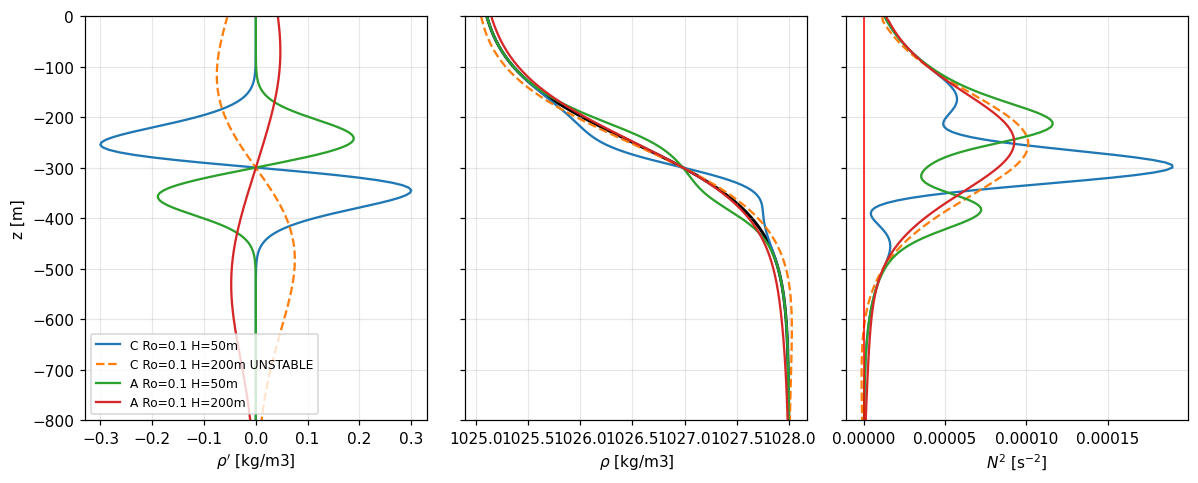

In [36]:
cases = [dict(polarity=p, Ro=0.1, R=15e3, H=h, z_eddy=-300.)
         for p in (+1, -1) for h in (50., 200.)]

fig, ax = plt.subplots(1, 3, figsize=(11, 4.5), sharey=True)
for c in cases:
    *_, ra, _ = build_eddy(z, rho_s, f0, **c, vshape=vshape, power_shape=power_shape,
                           balance=balance, L=L, n=n)
    rc = ra[:, ic, ic]
    n2 = -g/rho0*np.gradient(rho_s + rc)/np.gradient(z)
    bad = (n2[1:-1] < 0).sum() > 3
    lab = ('C' if c['polarity'] > 0 else 'A') + f" Ro={c['Ro']} H={c['H']:.0f}m" + (' UNSTABLE' if bad else '')
    ls = '--' if bad else '-'
    ax[0].plot(rc, z, ls, label=lab); ax[1].plot(rho_s + rc, z, ls); ax[2].plot(n2, z, ls)

ax[1].plot(rho_s, z, 'k', lw=2, zorder=0); ax[2].axvline(0, c='r', lw=1)
ax[0].set(xlabel=r"$\rho'$ [kg/m3]", ylabel='z [m]', ylim=(-800, 0))
ax[1].set_xlabel(r'$\rho$ [kg/m3]'); ax[2].set_xlabel(r'$N^2$ [s$^{-2}$]')
ax[0].legend(fontsize=8, loc='lower left'); plt.tight_layout(); plt.show()